# LeetCode #493: Reverse Pairs

https://leetcode.com/problems/reverse-pairs/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (nested loops)** | $O(n^2)$ | $O(1)$ |
| **Merge Sort (modified)** | $O(n \log n)$ | $O(n)$ |
| **Binary Indexed Tree (BIT) + Coordinate Compression** | $O(n \log n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force (nested loops)
For each element at index $i$, scan all $j > i$ and count pairs where `nums[i] > 2 * nums[j]`. Correct but $O(n^2)$ — too slow for $n = 5 \times 10^4$.

### Merge Sort (modified)
Before merging two sorted halves, count cross-half pairs using two pointers. Because both halves are sorted, once `left[i] > 2 * right[j]` fails for a given $i$, it fails for all smaller left values too — allowing $O(n)$ counting per merge step. Total: $O(n \log n)$.

### Optimal: Binary Indexed Tree (BIT) + Coordinate Compression ★
Compress all values and their doubles to 1-indexed ranks, then scan right to left. For each element `nums[i]`: query the BIT for elements already inserted whose value $v$ satisfies $v < \text{nums}[i] / 2$, i.e., rank $< \text{rank}(\text{nums}[i] / 2)$; then insert `nums[i]` into the BIT. Because `nums[i] > 2 * nums[j]` is equivalent to `nums[j] < nums[i] / 2`, we compress both the values and their halves to get exact rank boundaries.

**Why this is better than Merge Sort:** BIT is simpler to implement correctly — merge sort requires careful index management during the cross-count step. The BIT approach separates counting and insertion into clean, reusable primitives.

**Constraints:**
* 1 <= nums.length <= 5 * 10^4
* -2^31 <= nums[i] <= 2^31 - 1

## Solutions

### C#

In [ ]:
public class Solution {
    private int[] bit;
    private int n;

    public int ReversePairs(int[] nums) {
        // Compress nums[i] alongside 2*nums[j] values for exact rank splitting
        long[] all = nums.Select(x => (long)x)
                         .Concat(nums.Select(x => 2L * x))
                         .Distinct().OrderBy(x => x).ToArray();
        n = all.Length;
        bit = new int[n + 1];
        int rank(long v) => Array.BinarySearch(all, v) + 1;

        int count = 0;
        // Scan right to left: count then insert
        for (int i = nums.Length - 1; i >= 0; i--) {
            // Count j > i where nums[j]*2 < nums[i] — query prefix up to rank(nums[i])-1
            // since 2*nums[j] values are in the compressed array, rank(nums[i])-1 captures all 2*v < nums[i]
            count += Query(rank((long)nums[i]) - 1);
            // Insert 2*nums[i] so future elements to its left can count it
            Update(rank(2L * nums[i]), 1);
        }
        return count;
    }

    private void Update(int i, int delta) {
        for (; i <= n; i += i & -i) bit[i] += delta;
    }

    private int Query(int i) {
        int sum = 0;
        for (; i > 0; i -= i & -i) sum += bit[i];
        return sum;
    }
}

### Python

In [ ]:
class Solution:
    def reversePairs(self, nums: list[int]) -> int:
        # Compress nums[i] alongside 2*nums[j] for exact rank splitting
        all_vals = sorted(set(nums) | {2 * x for x in nums})
        rank = {v: i + 1 for i, v in enumerate(all_vals)}
        n = len(all_vals)
        bit = [0] * (n + 1)

        def update(i: int) -> None:
            while i <= n:
                bit[i] += 1
                i += i & -i

        def query(i: int) -> int:
            s = 0
            while i > 0:
                s += bit[i]
                i -= i & -i
            return s

        count = 0
        # Scan right to left: count then insert
        for v in reversed(nums):
            # Count j > i where 2*nums[j] < v — query prefix up to rank(v)-1
            count += query(rank[v] - 1)
            # Insert 2*v so future elements to its left can count it
            update(rank[2 * v])
        return count

### Go

In [ ]:
func reversePairs(nums []int) int {
    // Compress nums[i] alongside 2*nums[j] for exact rank splitting
    set := make(map[int]bool)
    for _, v := range nums {
        set[v] = true
        set[2*v] = true
    }
    sorted := make([]int, 0, len(set))
    for v := range set { sorted = append(sorted, v) }
    sort.Ints(sorted)
    rankOf := func(v int) int {
        lo, hi := 0, len(sorted)-1
        for lo <= hi {
            mid := (lo + hi) / 2
            if sorted[mid] == v { return mid + 1 }
            if sorted[mid] < v { lo = mid + 1 } else { hi = mid - 1 }
        }
        return -1
    }
    n := len(sorted)
    bit := make([]int, n+1)
    update := func(i int) {
        for ; i <= n; i += i & -i { bit[i]++ }
    }
    query := func(i int) int {
        s := 0
        for ; i > 0; i -= i & -i { s += bit[i] }
        return s
    }

    count := 0
    // Scan right to left: count then insert
    for i := len(nums) - 1; i >= 0; i-- {
        // Count j > i where 2*nums[j] < nums[i]
        count += query(rankOf(nums[i]) - 1)
        // Insert 2*nums[i] so future elements to its left can count it
        update(rankOf(2 * nums[i]))
    }
    return count
}

### Rust

In [ ]:
impl Solution {
    pub fn reverse_pairs(nums: Vec<i32>) -> i32 {
        // Compress nums[i] alongside 2*nums[j] for exact rank splitting
        use std::collections::BTreeSet;
        let mut all: BTreeSet<i64> = BTreeSet::new();
        for &v in &nums {
            all.insert(v as i64);
            all.insert(2 * v as i64);
        }
        let sorted: Vec<i64> = all.into_iter().collect();
        let rank = |v: i64| -> usize {
            sorted.partition_point(|&x| x < v) + 1
        };
        let n = sorted.len();
        let mut bit = vec![0i32; n + 1];

        let update = |bit: &mut Vec<i32>, mut i: usize| {
            while i <= n { bit[i] += 1; i += i & i.wrapping_neg(); }
        };
        let query = |bit: &Vec<i32>, mut i: usize| -> i32 {
            let mut s = 0;
            while i > 0 { s += bit[i]; i -= i & i.wrapping_neg(); }
            s
        };

        let mut count = 0i32;
        // Scan right to left: count then insert
        for &v in nums.iter().rev() {
            // Count j > i where 2*nums[j] < v
            count += query(&bit, rank(v as i64) - 1);
            // Insert 2*v so future elements to its left can count it
            update(&mut bit, rank(2 * v as i64));
        }
        count
    }
}

## Example Scenarios

**1. Common Case**
**Input:** nums = [1, 3, 2, 3, 1]
Scan right to left. Compressed array includes both values and their doubles.
- i=4, v=1: query(rank(1)-1)=query(rank(1)-1)=0, insert rank(2*1)=rank(2)
- i=3, v=3: query(rank(3)-1): count 2*j < 3, i.e., 2<3 so j=4 (2*1=2<3) → 1. Insert rank(6)
- i=2, v=2: query(rank(2)-1): count 2*j < 2 → none → 0. Insert rank(4)
- i=1, v=3: query(rank(3)-1): 2*1=2<3 (j=4) and 2*2=4≥3 → 1. Insert rank(6) (dup)
- i=0, v=1: query(rank(1)-1): count 2*j < 1 → none → 0. Insert rank(2)
Result: 0+1+0+1+0 = 2 pairs: (3,1) at indices (1,4) and (3,1) at indices (3,4).

**2. Slightly Complex**
**Input:** nums = [2, 4, 3, 5, 1]
- Reverse pairs require nums[i] > 2*nums[j]: (4,1)→4>2, (3,1)→3>2, (5,1)→5>2, (5,2)→5>4? No (5>4 ✓→ wait 5>2*2=4 yes).
- Pairs: (4,1), (3,1), (5,1), (5,2). Count = 3.
Each BIT query uses the compressed rank of nums[i] to count inserted 2*nums[j] values that are strictly less.

**3. Edge Case: Time Factor**
**Input:** nums = [n, n-1, …, 1] (reverse sorted, n = 5×10^4)
Every pair (i, j) where nums[i] > 2*nums[j] is a reverse pair. For value $k$ at index $n-k$, there are $\lfloor k/2 \rfloor$ valid $j$s to its right. Total pairs $\approx n^2/4$. But counting still runs in $O(n \log n)$ — BIT queries, not pair enumeration. Maximum BIT traversal depth: $O(\log(2n)) \approx 17$ for $n = 5 \times 10^4$.

**4. Edge Case: Space Factor**
**Input:** nums = all distinct values near $\pm 2^{31}$, n = 5×10^4
The compressed array holds both nums[i] and 2*nums[i] — up to $2n$ distinct values. BIT size = $2n+1 = 10^5 + 1$ integers ≈ 400 KB. Note: 2*nums[i] can overflow 32-bit int for nums[i] near $2^{31}$; all implementations cast to int64/long before doubling.

**5. Almost-Impossible but Plausible**
**Input:** nums = [2147483647, 1] (INT_MAX and 1)
$2 \times 1 = 2 < 2147483647$ → 1 reverse pair. Without int64 casting, `2 * nums[i]` overflows for INT_MAX. The BIT approach handles this by storing all values as `long`/`int64` before compression — the doubled value $2 \times \text{INT\_MAX} = 4294967294$ fits in int64. Without the cast, overflow produces a negative number that maps to a wrong rank, silently miscounting pairs.

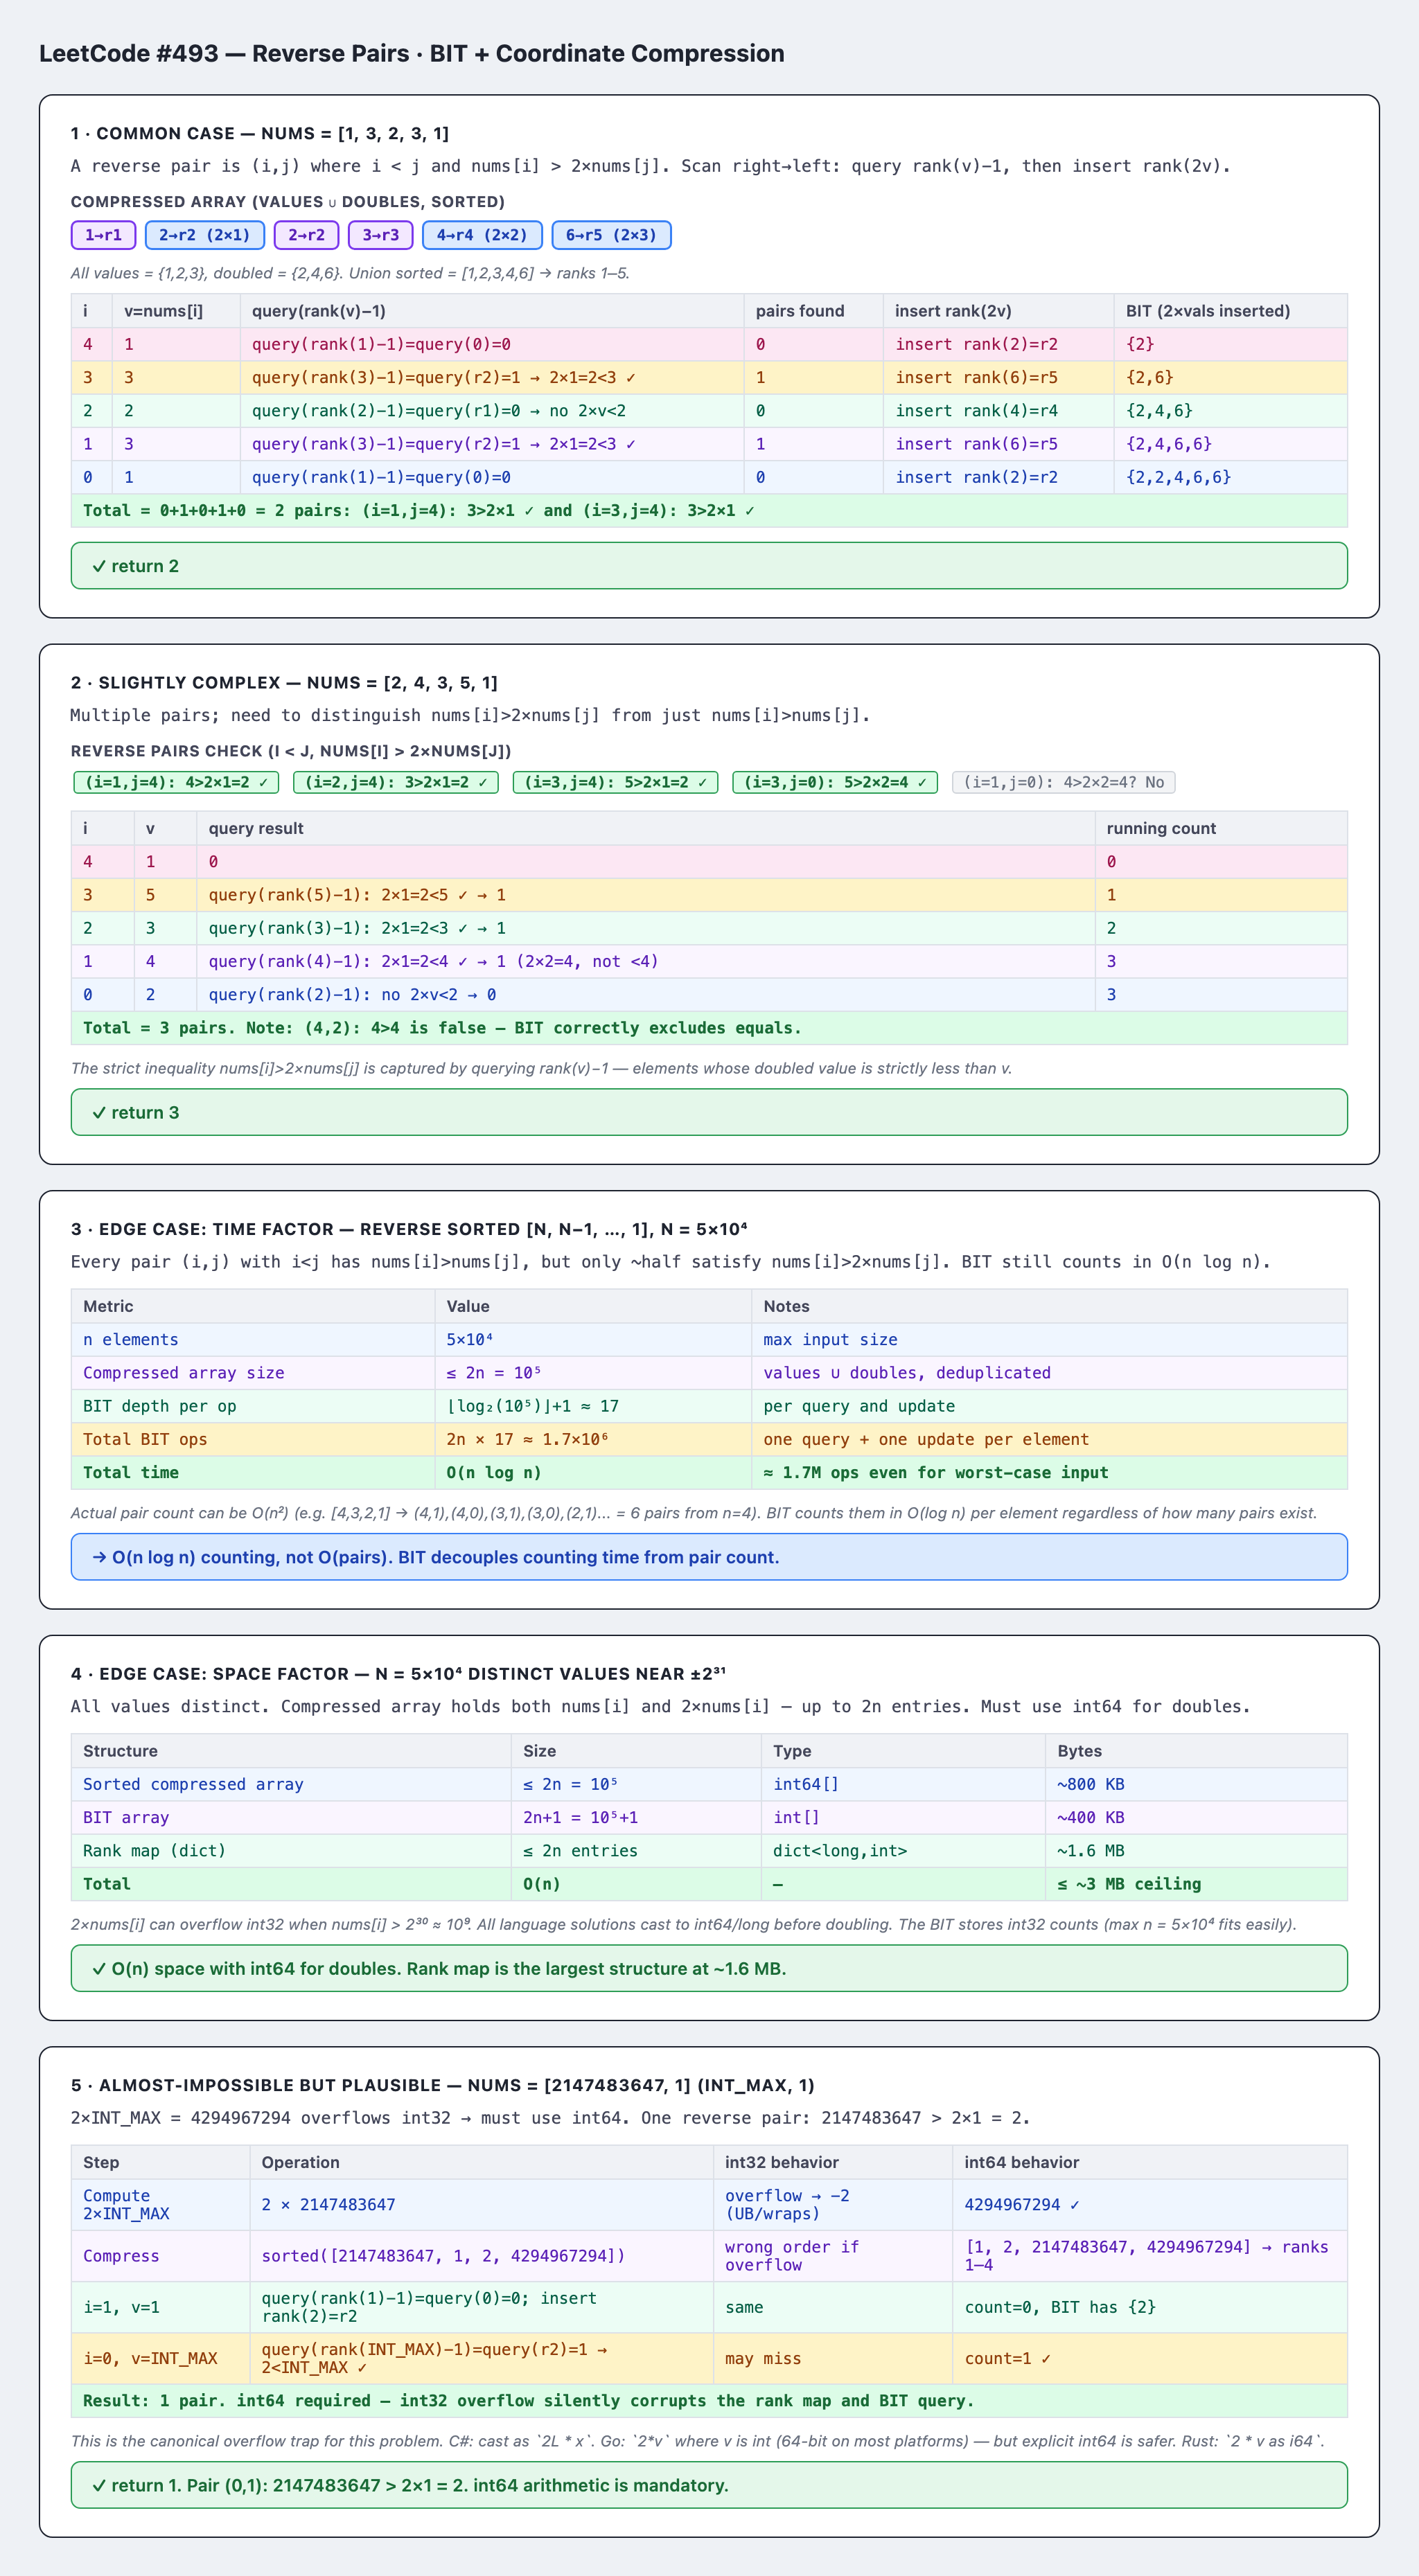